Section 1 – Regression with Abalone dataset (Kaggle)

Step 1 – Set up notebook and imports

In [2]:

# Adds the parent directory or current directory to the path
sys.path.append(os.path.abspath("."))  # Use ".." instead if your notebook is inside a subfolder

import sys
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor




Step 2 – Load sample_submission, train, and test

In [3]:
# Step 2: Load data
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

train.head(), test.head(), sample_submission.head()


(   id Sex  Length  Diameter  Height  Whole weight  Whole weight.1  \
 0   0   F   0.550     0.430   0.150        0.7715          0.3285   
 1   1   F   0.630     0.490   0.145        1.1300          0.4580   
 2   2   I   0.160     0.110   0.025        0.0210          0.0055   
 3   3   M   0.595     0.475   0.150        0.9145          0.3755   
 4   4   I   0.555     0.425   0.130        0.7820          0.3695   
 
    Whole weight.2  Shell weight  Rings  
 0          0.1465        0.2400     11  
 1          0.2765        0.3200     11  
 2          0.0030        0.0050      6  
 3          0.2055        0.2500     10  
 4          0.1600        0.1975      9  ,
       id Sex  Length  Diameter  Height  Whole weight  Whole weight.1  \
 0  90615   M   0.645     0.475   0.155        1.2380          0.6185   
 1  90616   M   0.580     0.460   0.160        0.9830          0.4785   
 2  90617   M   0.560     0.420   0.140        0.8395          0.3525   
 3  90618   M   0.570     0.490  

Step 3 – Inspect data and define features/target

In [4]:
# Step 3: Basic inspection
train.info()
train.describe(include="all")

# Define target and features
target_col = "Rings"          # adjust if your competition uses a different target name
X = train.drop(columns=[target_col])
y = train[target_col]

# Identify categorical and numeric columns
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

categorical_cols, numeric_cols


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90615 entries, 0 to 90614
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              90615 non-null  int64  
 1   Sex             90615 non-null  object 
 2   Length          90615 non-null  float64
 3   Diameter        90615 non-null  float64
 4   Height          90615 non-null  float64
 5   Whole weight    90615 non-null  float64
 6   Whole weight.1  90615 non-null  float64
 7   Whole weight.2  90615 non-null  float64
 8   Shell weight    90615 non-null  float64
 9   Rings           90615 non-null  int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 6.9+ MB


(['Sex'],
 ['id',
  'Length',
  'Diameter',
  'Height',
  'Whole weight',
  'Whole weight.1',
  'Whole weight.2',
  'Shell weight'])

Step 4 – Build preprocessing pipeline (encode categoricals)

In [5]:
# Step 4: Preprocessing
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)


Step 5 – Train/validation split for model evaluation

In [6]:
# Step 5: Train/validation split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Step 6 – First model: Linear Regression

In [7]:
# Step 6: Linear Regression model
linreg_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

linreg_model.fit(X_train, y_train)

y_valid_pred_lr = linreg_model.predict(X_valid)
rmse_lr = mean_squared_error(y_valid, y_valid_pred_lr, squared=False)
rmse_lr


2.0237293747136342

Step 7 – Second model: Random Forest Regression

In [7]:
# Step 7: Random Forest model
rf_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_valid_pred_rf = rf_model.predict(X_valid)
rmse_rf = mean_squared_error(y_valid, y_valid_pred_rf, squared=False)
rmse_rf


1.8935153237854618

Step 8 – Investigate regression assumptions
Use residuals from the validation set.

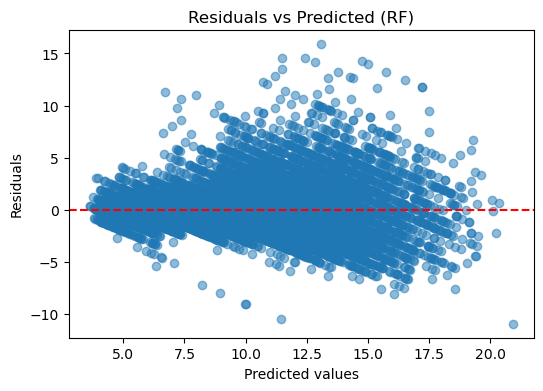

C:\Users\sjrey\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


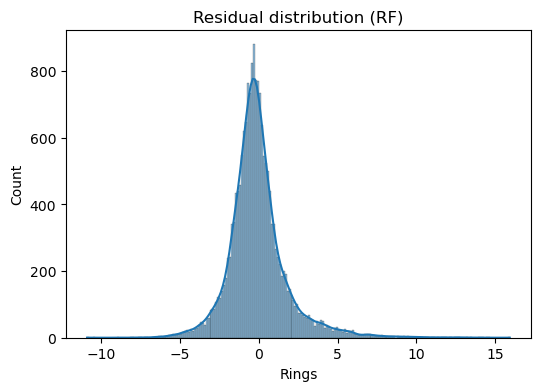

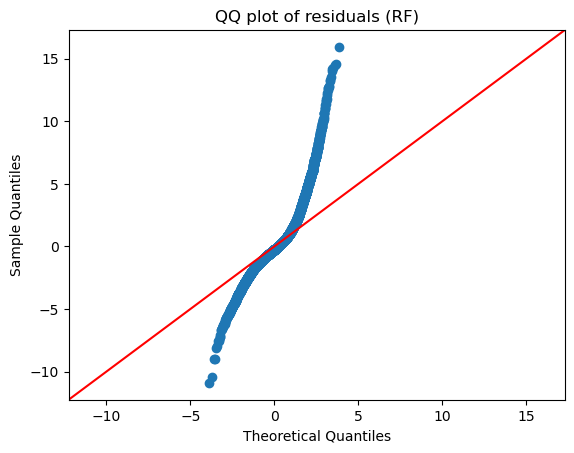

In [8]:
# Step 8: Assumption checks for Random Forest (or Linear Regression)
import matplotlib.pyplot as plt
import seaborn as sns

residuals_rf = y_valid - y_valid_pred_rf

# Linearity & residual patterns
plt.figure(figsize=(6,4))
plt.scatter(y_valid_pred_rf, residuals_rf, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (RF)")
plt.show()

# Distribution of residuals
plt.figure(figsize=(6,4))
sns.histplot(residuals_rf, kde=True)
plt.title("Residual distribution (RF)")
plt.show()

# QQ plot for residuals
import statsmodels.api as sm
sm.qqplot(residuals_rf, line="45")
plt.title("QQ plot of residuals (RF)")
plt.show()


Step 9 – Train chosen model on full training data and predict test

In [9]:
# Step 9: Final model on full training data
final_model = rf_model  # or linreg_model, depending on your comparison

final_model.fit(X, y)

test_predictions = final_model.predict(test)


Step 10 – Create submission file matching sample_submission format

In [10]:
# Step 10: Submission file
submission = sample_submission.copy()
submission[target_col] = test_predictions

submission.head()

submission.to_csv("my_abalone_submission.csv", index=False)


Section 2 – Conceptual Question #3 (ISLR Python)

Markdown cell for Q3 answers

Part (b): Plug IQ = 110 and GPA = 4.0 into the given regression equation from the book and show the calculation.

Part (c): Explain why a “small” interaction coefficient does not automatically mean “no interaction” (you must consider its standard error and p‑value).

### Conceptual Question #3 (ISLR Python)

**(b)** Predicted salary for college graduate with IQ = 110 and GPA = 4.0:



\[
\hat{Salary} = \beta_0 + \beta_1 \cdot \text{GPA} + \beta_2 \cdot \text{IQ} + \beta_3 \cdot \text{GPA}:\text{IQ} + \beta_4 \cdot \text{College} + \beta_5 \cdot \text{GPA}:\text{College}
\]



(Then substitute the coefficients from the text and compute.)

**(c)** Even if the interaction coefficient is numerically small, we must look at its **standard error** and **t‑statistic**. A small coefficient with a very small standard error can still be highly significant, indicating evidence of interaction.


Section 3 – Applied Question #10 (Carseats data)

Step 11 – Imports for Carseats analysis

In [11]:
# Step 11: Additional imports for Carseats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt


Step 12 – Load Carseats dataset

In [12]:
# Step 12: Load Carseats data
carseats = pd.read_csv("Carseats.csv")
carseats.head()
carseats.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   400 non-null    int64  
 1   Sales        400 non-null    float64
 2   CompPrice    400 non-null    int64  
 3   Income       400 non-null    int64  
 4   Advertising  400 non-null    int64  
 5   Population   400 non-null    int64  
 6   Price        400 non-null    int64  
 7   ShelveLoc    400 non-null    object 
 8   Age          400 non-null    int64  
 9   Education    400 non-null    int64  
 10  Urban        400 non-null    object 
 11  US           400 non-null    object 
dtypes: float64(1), int64(8), object(3)
memory usage: 37.6+ KB


Step 13 – Fit full model: Sales ~ Price + Urban + US

In [13]:
# Step 13: Full model
model_full = smf.ols("Sales ~ Price + Urban + US", data=carseats).fit()
print(model_full.summary())


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     41.52
Date:                Sat, 29 Aug 2026   Prob (F-statistic):           2.39e-23
Time:                        18:24:38   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1863.
Df Residuals:                     396   BIC:                             1879.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       13.0435      0.651     20.036   

Sales = β0 + β1 * Price + β2 * UrbanYes + β3 * USYes


Identify significant predictors (H₀: βᵢ = 0)

From model_full.summary():

    -Look at p‑values for Price, UrbanYes, USYes.
    -In Markdown, state which predictors have p‑value < 0.05 →      reject H₀.

Step 14 – Fit reduced model with only significant predictors

In [14]:
# Step 14: Reduced model
model_reduced = smf.ols("Sales ~ Price + US", data=carseats).fit()
print(model_reduced.summary())


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     62.43
Date:                Sat, 29 Aug 2026   Prob (F-statistic):           2.66e-24
Time:                        18:27:43   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1861.
Df Residuals:                     397   BIC:                             1873.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     13.0308      0.631     20.652      0.0

Step 15 – Compare fit of full vs reduced models
Use 𝑅2, adjusted 𝑅2, and possibly ANOVA.

In [15]:
# Step 15: Compare models
print("Full model R^2:", model_full.rsquared, "Adj R^2:", model_full.rsquared_adj)
print("Reduced model R^2:", model_reduced.rsquared, "Adj R^2:", model_reduced.rsquared_adj)

sm.stats.anova_lm(model_reduced, model_full)


Full model R^2: 0.23927539218405547 Adj R^2: 0.23351232697332858
Reduced model R^2: 0.23926288842678567 Adj R^2: 0.23543045965311715


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,397.0,2420.874462,0.0,NaN,NaN,NaN
1,396.0,2420.834671,1.0,0.03979,0.006509,0.935739


Step 16 – 95% confidence intervals for coefficients (reduced model)

In [16]:
# Step 16: Confidence intervals
model_reduced.conf_int(alpha=0.05)


,0,1
Intercept,11.79032,14.271265
US[T.Yes],0.69152,1.707766
Price,-0.06476,-0.044195


Step 17 – Diagnostic plots for reduced model

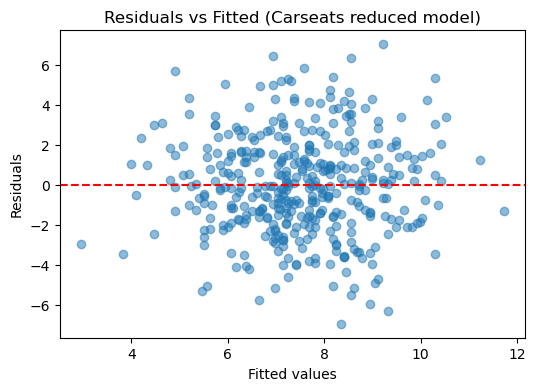

C:\Users\sjrey\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


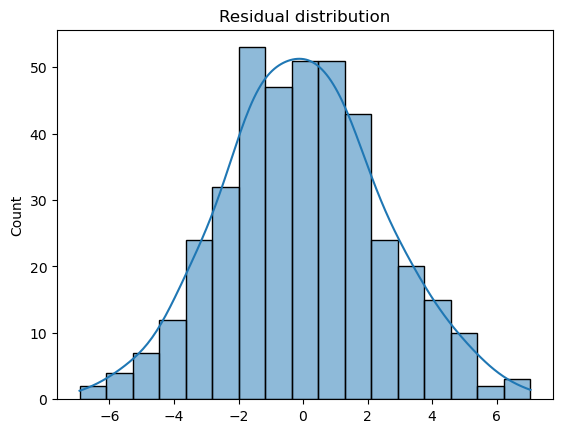

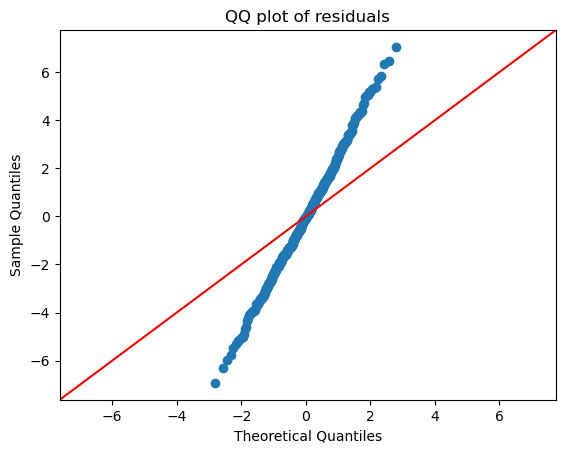

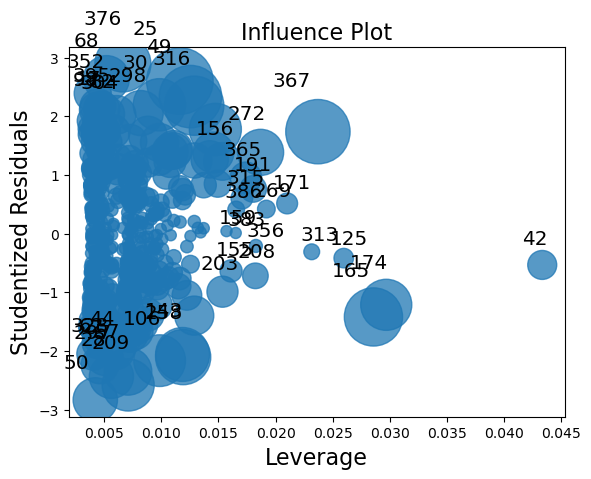

In [17]:
# Step 17: Diagnostic plots
residuals = model_reduced.resid
fitted = model_reduced.fittedvalues

# Residuals vs fitted
plt.figure(figsize=(6,4))
plt.scatter(fitted, residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Carseats reduced model)")
plt.show()

# Histogram of residuals
sns.histplot(residuals, kde=True)
plt.title("Residual distribution")
plt.show()

# QQ plot
sm.qqplot(residuals, line="45")
plt.title("QQ plot of residuals")
plt.show()

# Leverage plot
sm.graphics.influence_plot(model_reduced, criterion="cooks")
plt.show()
